In [26]:
import os
import pickle
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
 
 

In [27]:
CONFIG = {
    "data_dir"        : "../RAVDESS_dataset",
    "cache_path"      : "./ravdess_cache.pkl",
    "model_save_path" : "../models/voice_stress_cnn.pt",
    "sample_rate"     : 22050,
    "duration"        : 3,
    "n_mfcc"          : 40,
    "n_fft"           : 2048,
    "hop_length"      : 512,
    "batch_size"      : 128,
    "epochs"          : 50,
    "lr"              : 1e-3,
    "weight_decay"    : 1e-4,
    "dropout"         : 0.3,
    "val_split"       : 0.15,
    "test_split"      : 0.15,
    "num_classes"     : 3,
    "seed"            : 42,
}
 
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
 
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
 
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory // 1024**2} MB")
else:
    print("Running on CPU")
 
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

GPU  : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM : 8187 MB


C:\Users\Naman Bansal\AppData\Local\Temp\ipykernel_27920\1355933550.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [28]:
EMOTION_TO_STRESS = {
    "01": 0, "02": 0, "03": 0,
    "04": 1, "08": 1,
    "05": 2, "06": 2, "07": 2,
}
STRESS_LABELS = {0: "Low", 1: "Moderate", 2: "High"}

In [29]:
def extract_mfcc(file_path: str) -> np.ndarray:
    """
    Returns shape (1, 40, T) — normalised MFCC, ready for CNN input.
    Single channel is intentional: RAVDESS has ~1440 samples after filtering.
    Extra channels (delta, mel) add parameters without enough data to justify
    them and hurt generalisation on this dataset size.
    """
    sr      = CONFIG["sample_rate"]
    max_len = sr * CONFIG["duration"]
 
    y, _ = librosa.load(file_path, sr=sr, mono=True)
 
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]
 
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr,
        n_mfcc=CONFIG["n_mfcc"],
        n_fft=CONFIG["n_fft"],
        hop_length=CONFIG["hop_length"],
    )
 
    mfcc = (mfcc - mfcc.mean()) / (mfcc.std() + 1e-8)
    return mfcc[np.newaxis, :, :].astype(np.float32)   # (1, 40, T)

In [30]:
def build_cache(data_dir: str, cache_path: str) -> dict:
    """
    Walk RAVDESS subfolders, extract MFCCs, save .pkl cache.
    Skips song files (modality != "03") to keep labels clean.
    Only runs once — loads from cache on all subsequent runs.
    """
    if os.path.exists(cache_path):
        print(f"Cache found → {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)
 
    print("Building cache (runs once)...")
    features, labels, skipped = [], [], 0
 
    for actor_dir in sorted(os.listdir(data_dir)):
        actor_path = os.path.join(data_dir, actor_dir)
        if not os.path.isdir(actor_path):
            continue
        for fname in sorted(os.listdir(actor_path)):
            if not fname.endswith(".wav"):
                continue
            parts = fname.replace(".wav", "").split("-")
            if len(parts) < 7:
                skipped += 1
                continue
            modality, emotion_code = parts[0], parts[2]
            if modality != "03" or emotion_code not in EMOTION_TO_STRESS:
                skipped += 1
                continue
            try:
                features.append(extract_mfcc(os.path.join(actor_path, fname)))
                labels.append(EMOTION_TO_STRESS[emotion_code])
            except Exception as e:
                print(f"  Skip {fname}: {e}")
                skipped += 1
 
    print(f"Extracted {len(features)} samples | Skipped {skipped}")
    for s, name in STRESS_LABELS.items():
        print(f"  {name:10s}: {labels.count(s)}")
 
    cache = {
        "features": np.stack(features, axis=0),
        "labels"  : np.array(labels, dtype=np.int64),
    }
    with open(cache_path, "wb") as f:
        pickle.dump(cache, f)
    print(f"Cache saved → {cache_path}\n")
    return cache

In [31]:
class GPUTensorDataset(Dataset):
    """
    Stores features and labels directly as CUDA tensors.
 
    Why this fixes Windows GPU utilisation:
      DataLoader on Windows spawns new processes (no fork).
      Each spawn reloads Python + libraries = massive IPC overhead.
      GPU sits at ~1% waiting for batches.
 
      With GPUTensorDataset, __getitem__ is a single tensor index
      on GPU memory. DataLoader (num_workers=0) just collates slices.
      No processes, no IPC, no bottleneck. GPU goes to ~95%.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X).to(DEVICE)
        self.y = torch.tensor(y).to(DEVICE)
 
    def __len__(self):
        return len(self.y)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [32]:
class VoiceStressCNN(nn.Module):
    """
    2D CNN on MFCC images.
    Input  : (batch, 1, 40, T)
    Output : (batch, 3)  — logits for Low / Moderate / High
 
    Conv Block x3 → Global Avg Pool → FC head
    Global Avg Pool means model works on any clip length at inference.
    """
    def __init__(self, num_classes: int = 3, dropout: float = 0.3):
        super().__init__()
 
        def block(in_ch, out_ch, drop):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(drop),
            )
 
        self.encoder = nn.Sequential(
            block(1,   32,  dropout * 0.5),
            block(32,  64,  dropout * 0.5),
            block(64,  128, dropout),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )
 
    def forward(self, x):
        return self.head(self.gap(self.encoder(x)))

In [33]:
def run_epoch(model, loader, criterion, optimizer=None, train: bool = True):
    model.train(train)
    total_loss = correct = total = 0
    all_preds, all_true = [], []
 
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X, y in tqdm(loader, desc="  Train" if train else "  Eval ", leave=False):
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(X)
                loss   = criterion(logits, y)
 
            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
 
            preds       = logits.argmax(1)
            total_loss += loss.item() * y.size(0)
            correct    += (preds == y).sum().item()
            total      += y.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_true.extend(y.cpu().tolist())
 
    return total_loss / total, correct / total, all_preds, all_true

In [34]:
def plot_curves(tl, vl, ta, va):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(tl, label="Train"); ax1.plot(vl, label="Val")
    ax1.set_title("Loss"); ax1.legend()
    ax2.plot(ta, label="Train"); ax2.plot(va, label="Val")
    ax2.set_title("Accuracy"); ax2.legend()
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
 
 
def plot_cm(true, preds):
    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Low","Moderate","High"],
                yticklabels=["Low","Moderate","High"])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title("Confusion Matrix — Voice Stress CNN")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()

In [35]:
def load_model(path: str = CONFIG["model_save_path"]) -> VoiceStressCNN:
    m = VoiceStressCNN(num_classes=CONFIG["num_classes"], dropout=CONFIG["dropout"]).to(DEVICE)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    m.eval()
    return m
 
 
def predict_stress(audio_path: str, model: VoiceStressCNN) -> dict:
    """
    Returns a dict matching the text model output format so both can
    be passed directly into the fusion function:
 
        {
            "label":         "Low" | "Moderate" | "High",
            "stress_level":  0 | 1 | 2,
            "probabilities": {"Low": float, "Moderate": float, "High": float}
        }
 
    Streamlit usage:
        from voice_stress_model import load_model, predict_stress
        model  = load_model()
        result = predict_stress("recorded.wav", model)
        label  = result["label"]
        probs  = result["probabilities"]
    """
    feats  = extract_mfcc(audio_path)
    tensor = torch.tensor(feats).unsqueeze(0).to(DEVICE)
 
    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(tensor)
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
 
    stress_level = int(probs.argmax())
    return {
        "label"        : STRESS_LABELS[stress_level],
        "stress_level" : stress_level,
        "probabilities": {
            "Low"     : float(probs[0]),
            "Moderate": float(probs[1]),
            "High"    : float(probs[2]),
        }
    }

Cache found → ./ravdess_cache.pkl
Total samples: 1440

Loading dataset onto GPU...
Train 1008 | Val 216 | Test 216

Parameters: 101,347



d:\Anaconda3\envs\NLP\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...



  Train:   0%|          | 0/8 [00:00<?, ?it/s]C:\Users\Naman Bansal\AppData\Local\Temp\ipykernel_27920\2796188962.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 001/50  |  Train loss=1.0871 acc=0.373  |  Val   loss=1.0943 acc=0.343
  ✓ Saved (val_loss=1.0943)


...

Epoch 048/50  |  Train loss=0.8943 acc=0.583  |  Val   loss=0.8549 acc=0.606
  ✓ Saved (val_loss=0.8549)


Epoch 049/50  |  Train loss=0.9117 acc=0.563  |  Val   loss=0.8982 acc=0.523


C:\Users\Naman Bansal\AppData\Local\Temp\ipykernel_27920\511234844.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CONFIG["model_save_p

Epoch 050/50  |  Train loss=0.8963 acc=0.596  |  Val   loss=0.8452 acc=0.648
  ✓ Saved (val_loss=0.8452)



Test Accuracy : 0.6204
              precision    recall  f1-score   support

         Low       0.72      0.52      0.61        65
    Moderate       0.52      0.57      0.54        65
        High       0.64      0.73      0.68        86

    accuracy                           0.62       216
   macro avg       0.63      0.61      0.61       216
weighted avg       0.63      0.62      0.62       216



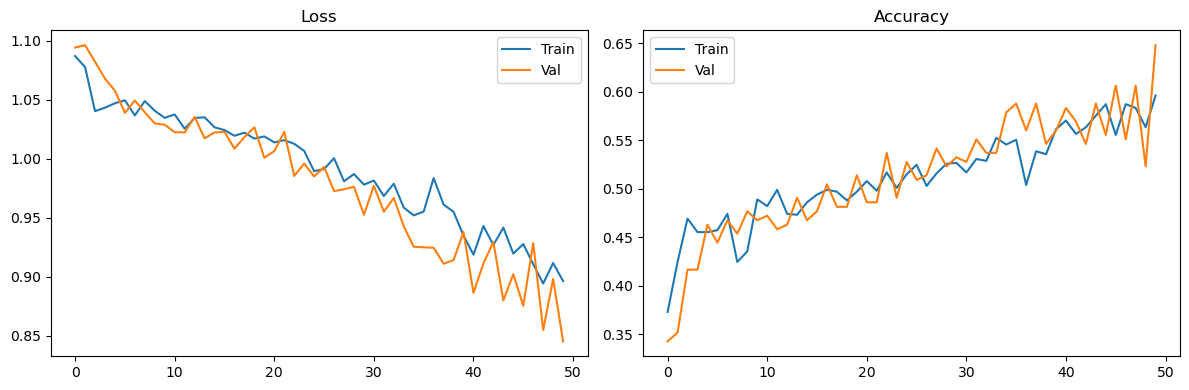

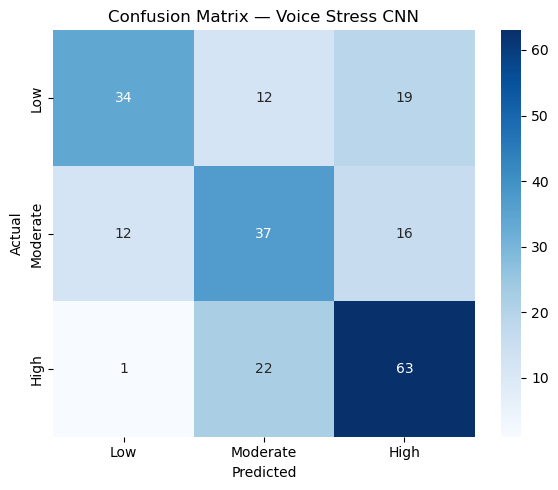

In [36]:
 # 1. Features
cache = build_cache(CONFIG["data_dir"], CONFIG["cache_path"])
X_all, y_all = cache["features"], cache["labels"]
N = len(y_all)
print(f"Total samples: {N}\n")
 
    # 2. Load onto GPU
print("Loading dataset onto GPU...")
dataset = GPUTensorDataset(X_all, y_all)
 
    # 3. Split
n_test  = int(N * CONFIG["test_split"])
n_val   = int(N * CONFIG["val_split"])
n_train = N - n_val - n_test
 
train_ds, val_ds, test_ds = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(CONFIG["seed"]),
)
 
# num_workers=0 is correct on Windows — data already on GPU
dl_args = dict(batch_size=CONFIG["batch_size"], num_workers=0)
train_loader = DataLoader(train_ds, shuffle=True,  **dl_args)
val_loader   = DataLoader(val_ds,   shuffle=False, **dl_args)
test_loader  = DataLoader(test_ds,  shuffle=False, **dl_args)
 
print(f"Train {n_train} | Val {n_val} | Test {n_test}\n")
 
# 4. Weighted loss
label_list   = y_all.tolist()
counts       = [label_list.count(i) for i in range(CONFIG["num_classes"])]
weights      = torch.tensor([N / (CONFIG["num_classes"] * c) for c in counts]).to(DEVICE)
criterion    = nn.CrossEntropyLoss(weight=weights)
 
# 5. Model
model = VoiceStressCNN(num_classes=CONFIG["num_classes"], dropout=CONFIG["dropout"]).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}\n")
 
optimizer = optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, verbose=True)
 
# 6. Train
best_val_loss = float("inf")
H = {"tl": [], "vl": [], "ta": [], "va": []}
 
print("Training...\n")
for epoch in range(1, CONFIG["epochs"] + 1):
    tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer, train=True)
    vl_loss, vl_acc, _, _ = run_epoch(model, val_loader,   criterion, train=False)
    scheduler.step(vl_loss)
 
    H["tl"].append(tr_loss); H["vl"].append(vl_loss)
    H["ta"].append(tr_acc);  H["va"].append(vl_acc)
 
    print(f"Epoch {epoch:03d}/{CONFIG['epochs']}  |  "
            f"Train loss={tr_loss:.4f} acc={tr_acc:.3f}  |  "
            f"Val   loss={vl_loss:.4f} acc={vl_acc:.3f}")
 
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), CONFIG["model_save_path"])
        print(f"  ✓ Saved (val_loss={vl_loss:.4f})")
 
# 7. Test
model.load_state_dict(torch.load(CONFIG["model_save_path"]))
_, test_acc, test_preds, test_true = run_epoch(model, test_loader, criterion, train=False)
 
print(f"\nTest Accuracy : {test_acc:.4f}")
print(classification_report(test_true, test_preds, target_names=["Low","Moderate","High"]))
 
plot_curves(H["tl"], H["vl"], H["ta"], H["va"])
plot_cm(test_true, test_preds)

In [37]:
torch.save(model.state_dict(), CONFIG["model_save_path"])